In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from scipy.stats import norm

In [2]:
df = pd.read_csv('../data/updated_data.csv')

In [3]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

selected_covariates = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

offset = df["wr_men"].to_numpy()
offset = offset / 100
offset_star = np.log(offset / (1 - offset))

N = 107 
P = len(selected_covariates) 
K = 3 

In [4]:
mix_model = """
data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;          
  vector[N] offset_star;        
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  matrix[K, P] beta;       
  real<lower=0> sigma;     
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K));   // Dirichlet(1,...,1)

  for (k in 1:K) {
    alpha[k] ~ normal(0, 5);
    for (j in 1:P) {
      beta[k, j] ~ normal(0, 5);
    }
  }

  sigma ~ normal(0, 1);   // half-normal(0,1)

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta[k]) + offset_star[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  vector[N] y_star_rep;
  vector[N] y_rep;  // in (0, 1), same scale as y

  for (i in 1:N) {
    int z;          // mixture component
    real mu_ik;

    // Sample component for observation i
    z = categorical_rng(pi);

    // Linear predictor for that component
    mu_ik = alpha[z] + dot_product(row(X_star, i), beta[z]) + offset_star[i];

    // Sample from Normal on logit scale
    y_star_rep[i] = normal_rng(mu_ik, sigma);

    // Transform back to proportion space
    y_rep[i] = inv_logit(y_star_rep[i]);
  }
}

"""

In [5]:
with open("normal_mixture.stan", "w") as f:
    f.write(mix_model)

In [6]:
data = {
    "N": int(N),
    "P": int(P),
    "K": int(K),
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
    "offset_star": offset_star.astype(float),
}


In [7]:
mix_stan = CmdStanModel(stan_file="normal_mixture.stan")

13:45:44 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture.exe
13:48:51 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture.exe


In [8]:
fit = mix_stan.sample(
    data=data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    adapt_delta=0.95,
    seed=42
)

13:50:00 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

13:54:17 - cmdstanpy - INFO - CmdStan done processing.


13:54:17 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 4 had 8 iterations at max treedepth (0.4%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


## Extending Tommy Notebook

In [ ]:
y_star_rep = fit.stan_variable("y_star_rep")
y_star_rep = np.asarray(y_star_rep) 
y_star_rep_flat = y_star_rep.reshape(-1)  

(856000,) (8000, 107)


Plots

In [69]:
alpha_draws = fit.stan_variable("alpha")   # (S, K)
beta_draws  = fit.stan_variable("beta")    # (S, K, P)
sigma_draws = fit.stan_variable("sigma")   # (S,)
pi_draws    = fit.stan_variable("pi")      # (S, K)

alpha_mean = alpha_draws.mean(axis=0)      # (K,)
beta_mean  = beta_draws.mean(axis=0)       # (K, P)
sigma_mean = sigma_draws.mean()
pi_mean    = pi_draws.mean(axis=0)         # (K,)

In [70]:
S = alpha_draws.shape[0]   # number of posterior draws
y_star_grid = np.linspace(y_star.min()-1, y_star.max()+1, 300)

mix_density = np.zeros((S, len(y_star_grid)))
comp_density = np.zeros((S, K, len(y_star_grid)))

In [71]:
for s in range(S):
    alpha_s = alpha_draws[s]
    beta_s  = beta_draws[s]
    sigma_s = sigma_draws[s]
    pi_s    = pi_draws[s]
    
    mu_ik_s = (
        alpha_s[None, :] +
        offset_star[:, None] +
        X_star @ beta_s.T
    )
    
    for k in range(K):
        dens_ik = norm.pdf(y_star_grid[None, :], loc=mu_ik_s[:, k:k+1], scale=sigma_s)
        comp_density[s, k, :] = pi_s[k] * dens_ik.mean(axis=0)
    
    mix_density[s, :] = comp_density[s].sum(axis=0)

# posterior mean mixture density
mix_mean = mix_density.mean(axis=0)
comp_mean = comp_density.mean(axis=0)

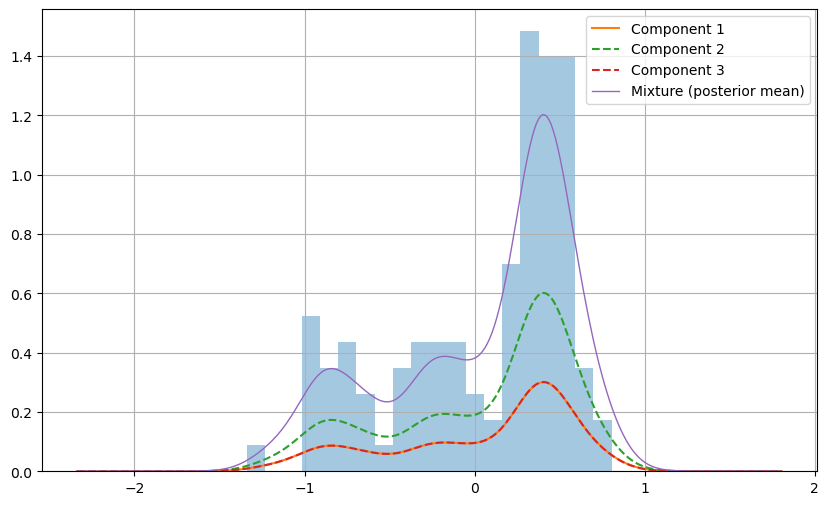

In [85]:
plt.figure(figsize=(10, 6))
plt.hist(y_star, bins=20, density=True, alpha=0.4)

plt.plot(y_star_grid, comp_mean[0], "-", label=f"Component {1}")
plt.plot(y_star_grid, comp_mean[1], "--", label=f"Component {2}")
plt.plot(y_star_grid, comp_mean[2], "--", label=f"Component {3}")

plt.grid(True)
plt.plot(y_star_grid, mix_mean, label="Mixture (posterior mean)", linewidth=1)
plt.legend()
plt.show()

### "marginal" mixture

In [ ]:
normal_mix = """
data {
  int<lower=1> N;
  int<lower=1> K;
  vector[N] y_star;
}

parameters {
  simplex[K] pi;
  vector[K] mu;
  vector<lower=0>[K] sigma;
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K));
  mu ~ normal(0, 5);
  sigma ~ normal(0, 1);

  // Likelihood (mixture)
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu[k], sigma[k]);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  vector[N] y_star_rep;
  array[N] int z_rep;   
  for (i in 1:N) {
    z_rep[i] = categorical_rng(pi);
    y_star_rep[i] = normal_rng(mu[z_rep[i]], sigma[z_rep[i]]);
  }
}
"""

In [14]:
with open("normal_mix.stan", "w") as f:
    f.write(normal_mix)

In [15]:
data = {
    "N": int(N),
    "K": int(K),
    "y_star": y_star.astype(float),
}

In [16]:
normal_stan = CmdStanModel(stan_file="normal_mix.stan")

12:40:47 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mix.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mix.exe
12:42:14 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mix.exe


In [17]:
fit = normal_stan.sample(
    data=data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    adapt_delta=0.95,
    seed=42
)

12:42:18 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

12:42:57 - cmdstanpy - INFO - CmdStan done processing.
12:42:57 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'normal_mix.stan', line 24, column 6 to column 69)
Consider re-running with show_console=True if the above output is unclear!
12:42:57 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 2 had 71 iterations at max treedepth (3.5%)
	Chain 3 had 87 iterations at max treedepth (4.3%)
	Chain 4 had 341 iterations at max treedepth (17.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


Plots

In [22]:
y_star_rep = fit.stan_variable("y_star_rep")
y_star_rep = np.asarray(y_star_rep) 
y_star_rep_flat = y_star_rep.reshape(-1)  

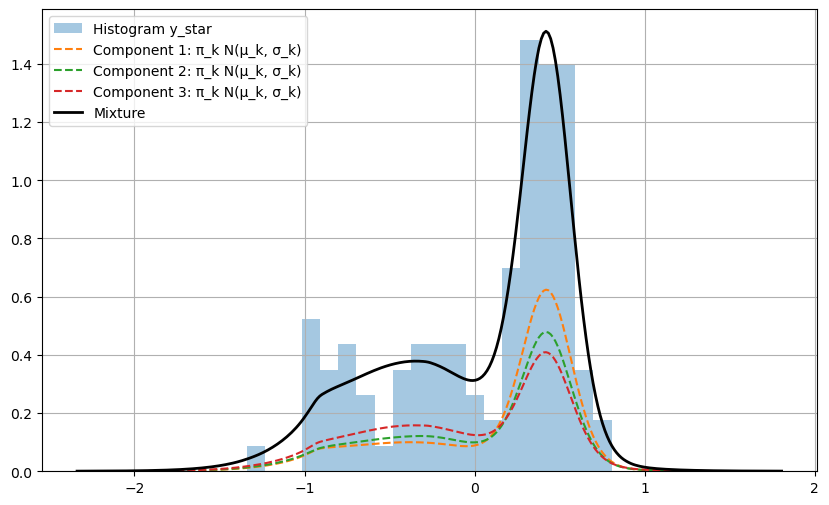

In [ ]:
pi_draws    = fit.stan_variable("pi")     # (S, K)
mu_draws    = fit.stan_variable("mu")     # (S, K)
sigma_draws = fit.stan_variable("sigma") # (S, K)

S, K = pi_draws.shape

y_star_grid = np.linspace(y_star.min() - 1, y_star.max() + 1, 300)

mix_density  = np.zeros((S, len(y_star_grid)))
comp_density = np.zeros((S, K, len(y_star_grid)))

for s in range(S):
    for k in range(K):
        comp_density[s, k, :] = (
            pi_draws[s, k]
            * norm.pdf(
                y_star_grid,
                loc=mu_draws[s, k],
                scale=sigma_draws[s, k]
            )
        )

    mix_density[s, :] = comp_density[s].sum(axis=0)

mix_mean  = mix_density.mean(axis=0)
comp_mean = comp_density.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.hist(y_star, bins=20, density=True, alpha=0.4, label="Histogram y_star")

for k in range(K):
    plt.plot(
        y_star_grid,
        comp_mean[k],
        "--",
        label=f"Component {k+1}: π_k N(μ_k, σ_k)"
    )

plt.plot(
    y_star_grid,
    mix_mean,
    "k-",
    linewidth=2,
    label="Mixture"
)

plt.grid(True)
plt.legend()
plt.show()

# PyMC

In [28]:
n_feat = N
n_components = 3

In [29]:
with pm.Model() as bl_model:
    y_data = pm.Data("y_data", y_star)

    mu = pm.Normal(
        "mu",
        mu=y_data.mean(),
        sigma=10,
        shape=n_components,
        transform=pm.distributions.transforms.ordered,
        initval=[1, 2, 3],
    )

    sigma = pm.HalfNormal("sigma", sigma=10, shape=n_components)

    weights = pm.Dirichlet("w", np.ones(n_components))

    y_obs = pm.NormalMixture(
        "y_obs", w=weights, mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

c:\Users\leona\miniconda3\envs\bayesian\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
c:\Users\leona\miniconda3\envs\bayesian\lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that

Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 71 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


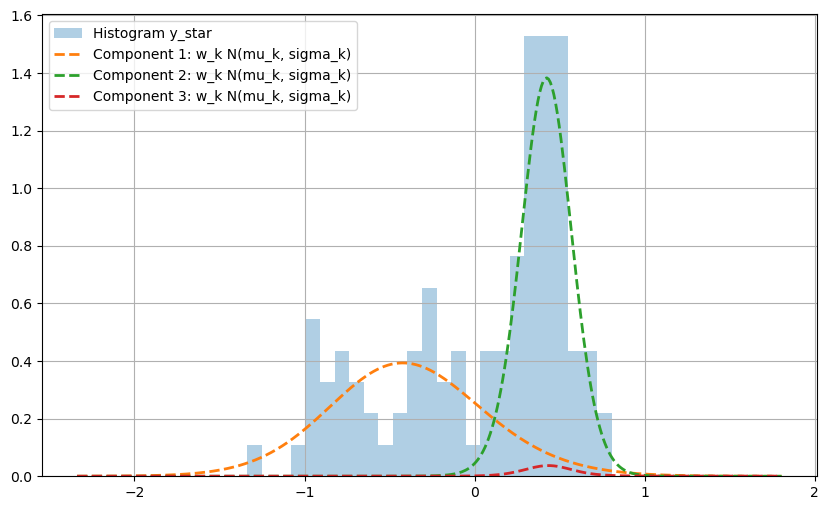

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

y = y_star

post = trace.posterior

mu = post["mu"].values
sigma = post["sigma"].values
w = post["w"].values

S = mu.shape[0] * mu.shape[1]
K = mu.shape[2]

mu = mu.reshape(S, K)
sigma = sigma.reshape(S, K)
w = w.reshape(S, K)

x = np.linspace(y.min() - 1, y.max() + 1, 400)

comp_density = np.zeros((S, K, x.size))
mix_density = np.zeros((S, x.size))

for s in range(S):
    for k in range(K):
        comp_density[s, k, :] = w[s, k] * st.norm.pdf(x, loc=mu[s, k], scale=sigma[s, k])
    mix_density[s, :] = comp_density[s].sum(axis=0)


comp_mean = comp_density.mean(axis=0)     
mix_mean = mix_density.mean(axis=0)       


plt.figure(figsize=(10, 6))
plt.hist(y, bins=25, density=True, alpha=0.35, label="Histogram y_star")

for k in range(K):
    plt.plot(x, comp_mean[k], "--", linewidth=2, label=f"Component {k+1}: w_k N(mu_k, sigma_k)")

# plt.plot(x, mix_mean, "k-", linewidth=2.5, label="Mixture")
plt.grid(True)
plt.legend()
plt.show()
